In [1]:
import pandas as pd

df = pd.read_csv("results/partial/scalabilityApproaches_all_methods_v1_partial.csv")

In [5]:
for i in df.columns:
    print(i)

risk
K
n
seed
gamma
alpha
epsilon
epsilon_scr
kappa
tau
max_candidates
n_screen_starts
n_support_starts
screen_maxiter
support_maxiter
stochastic_max_iter
stochastic_minibatch_size
methods
mcp_success
mcp_time_s
mcp_eta
mcp_regret1
mcp_regret2
mcp_has_profile
mcp_error
mcp_solver
mcp_candidate_index
mcp_support_eta
mcp_screen_eta
mcp_support_violation
mcp_residual_norm
mcp_objective
mcp_iterations
mcp_best_certificate_eta
screened_dual_success
screened_dual_time_s
screened_dual_eta
screened_dual_regret1
screened_dual_regret2
screened_dual_has_profile
screened_dual_error
screened_dual_solver
screened_dual_candidate_index
screened_dual_support_eta
screened_dual_screen_eta
screened_dual_support_violation
screened_dual_residual_norm
screened_dual_objective
screened_dual_iterations
screened_dual_best_certificate_eta
action_dual_success
action_dual_time_s
action_dual_eta
action_dual_regret1
action_dual_regret2
action_dual_has_profile
action_dual_error
action_dual_solver
action_dual_candidate

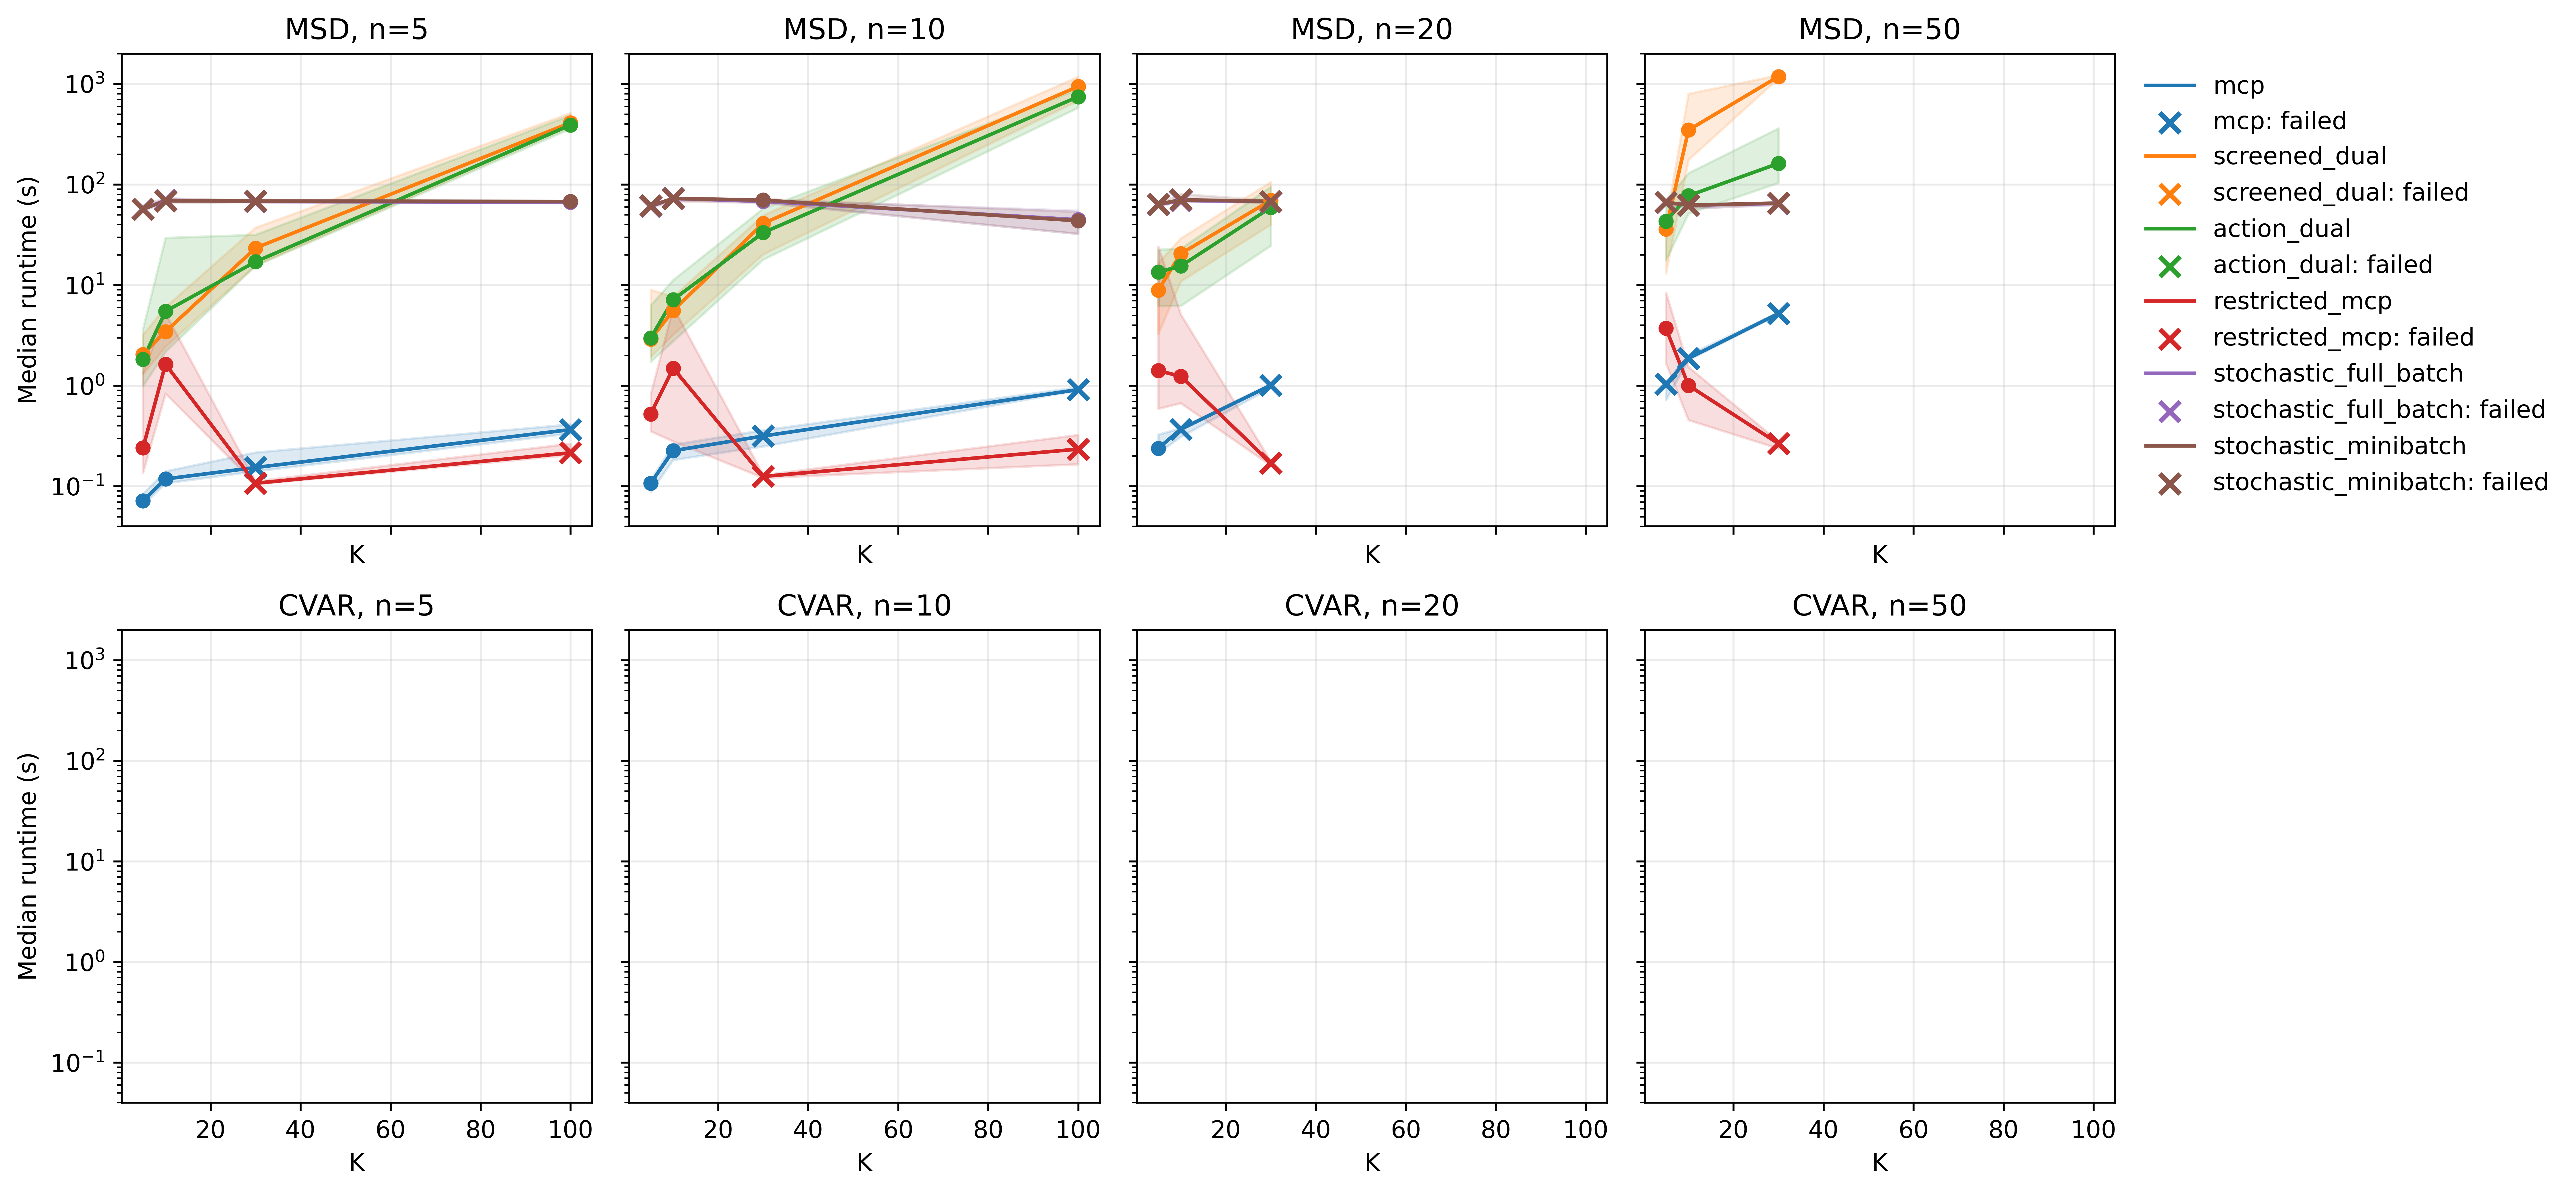

In [ ]:
import matplotlib.pyplot as plt

K_grid = [5, 10, 30, 100, 250, 500]
n_grid = [5, 10, 20, 50]
risk_grid = ["msd", "cvar"]

fig, axes = plt.subplots(
    len(risk_grid),
    len(n_grid),
    figsize=(15, 7),
    dpi=600,
    sharey=True,
    sharex=True,
)

methods = [m.strip() for m in df["methods"].iloc[0].split(",")]
cmap = plt.get_cmap("tab10")
color_dict = {m: cmap(i % cmap.N) for i, m in enumerate(methods)}

for row, risk in enumerate(risk_grid):
    for col, n in enumerate(n_grid):
        ax = axes[row, col]
        s = df[(df["n"] == n) & (df["risk"] == risk)].sort_values("K")

        for method in methods:
            method_df = s.groupby("K", as_index=False).agg(
                **{
                    f"{method}_reps": ("seed", "count"),
                    f"{method}_time_median": (f"{method}_time_s", "median"),
                    f"{method}_time_q25": (
                        f"{method}_time_s",
                        lambda x: x.quantile(0.25),
                    ),
                    f"{method}_time_q75": (
                        f"{method}_time_s",
                        lambda x: x.quantile(0.75),
                    ),
                    f"{method}_eta_median": (f"{method}_eta", "median"),
                    f"{method}_succ_n": (f"{method}_success", "sum"),
                }
            )

            if method_df.empty:
                continue

            method_zero = method_df[f"{method}_succ_n"] == 0

            ax.plot(
                method_df["K"],
                method_df[f"{method}_time_median"],
                "-",
                label=method if row == 0 and col == len(n_grid) - 1 else "_nolegend_",
                color=color_dict[method],
            )
            ax.fill_between(
                method_df["K"],
                method_df[f"{method}_time_q25"],
                method_df[f"{method}_time_q75"],
                alpha=0.15,
                label="_nolegend_",
                color=color_dict[method],
            )
            ax.scatter(
                method_df.loc[~method_zero, "K"],
                method_df.loc[~method_zero, f"{method}_time_median"],
                marker="o",
                s=28,
                zorder=4,
                color=color_dict[method],
            )
            ax.scatter(
                method_df.loc[method_zero, "K"],
                method_df.loc[method_zero, f"{method}_time_median"],
                marker="x",
                s=70,
                linewidths=2.0,
                label=(
                    f"{method}: failed"
                    if row == 0 and col == len(n_grid) - 1
                    else "_nolegend_"
                ),
                zorder=5,
                color=color_dict[method],
            )

        ax.set_yscale("log")
        ax.set_title(f"{risk.upper()}, n={n}")
        ax.set_xlabel("K")
        ax.grid(alpha=0.25)

    axes[row, 0].set_ylabel(f"Median runtime (s)")

axes[0, -1].legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

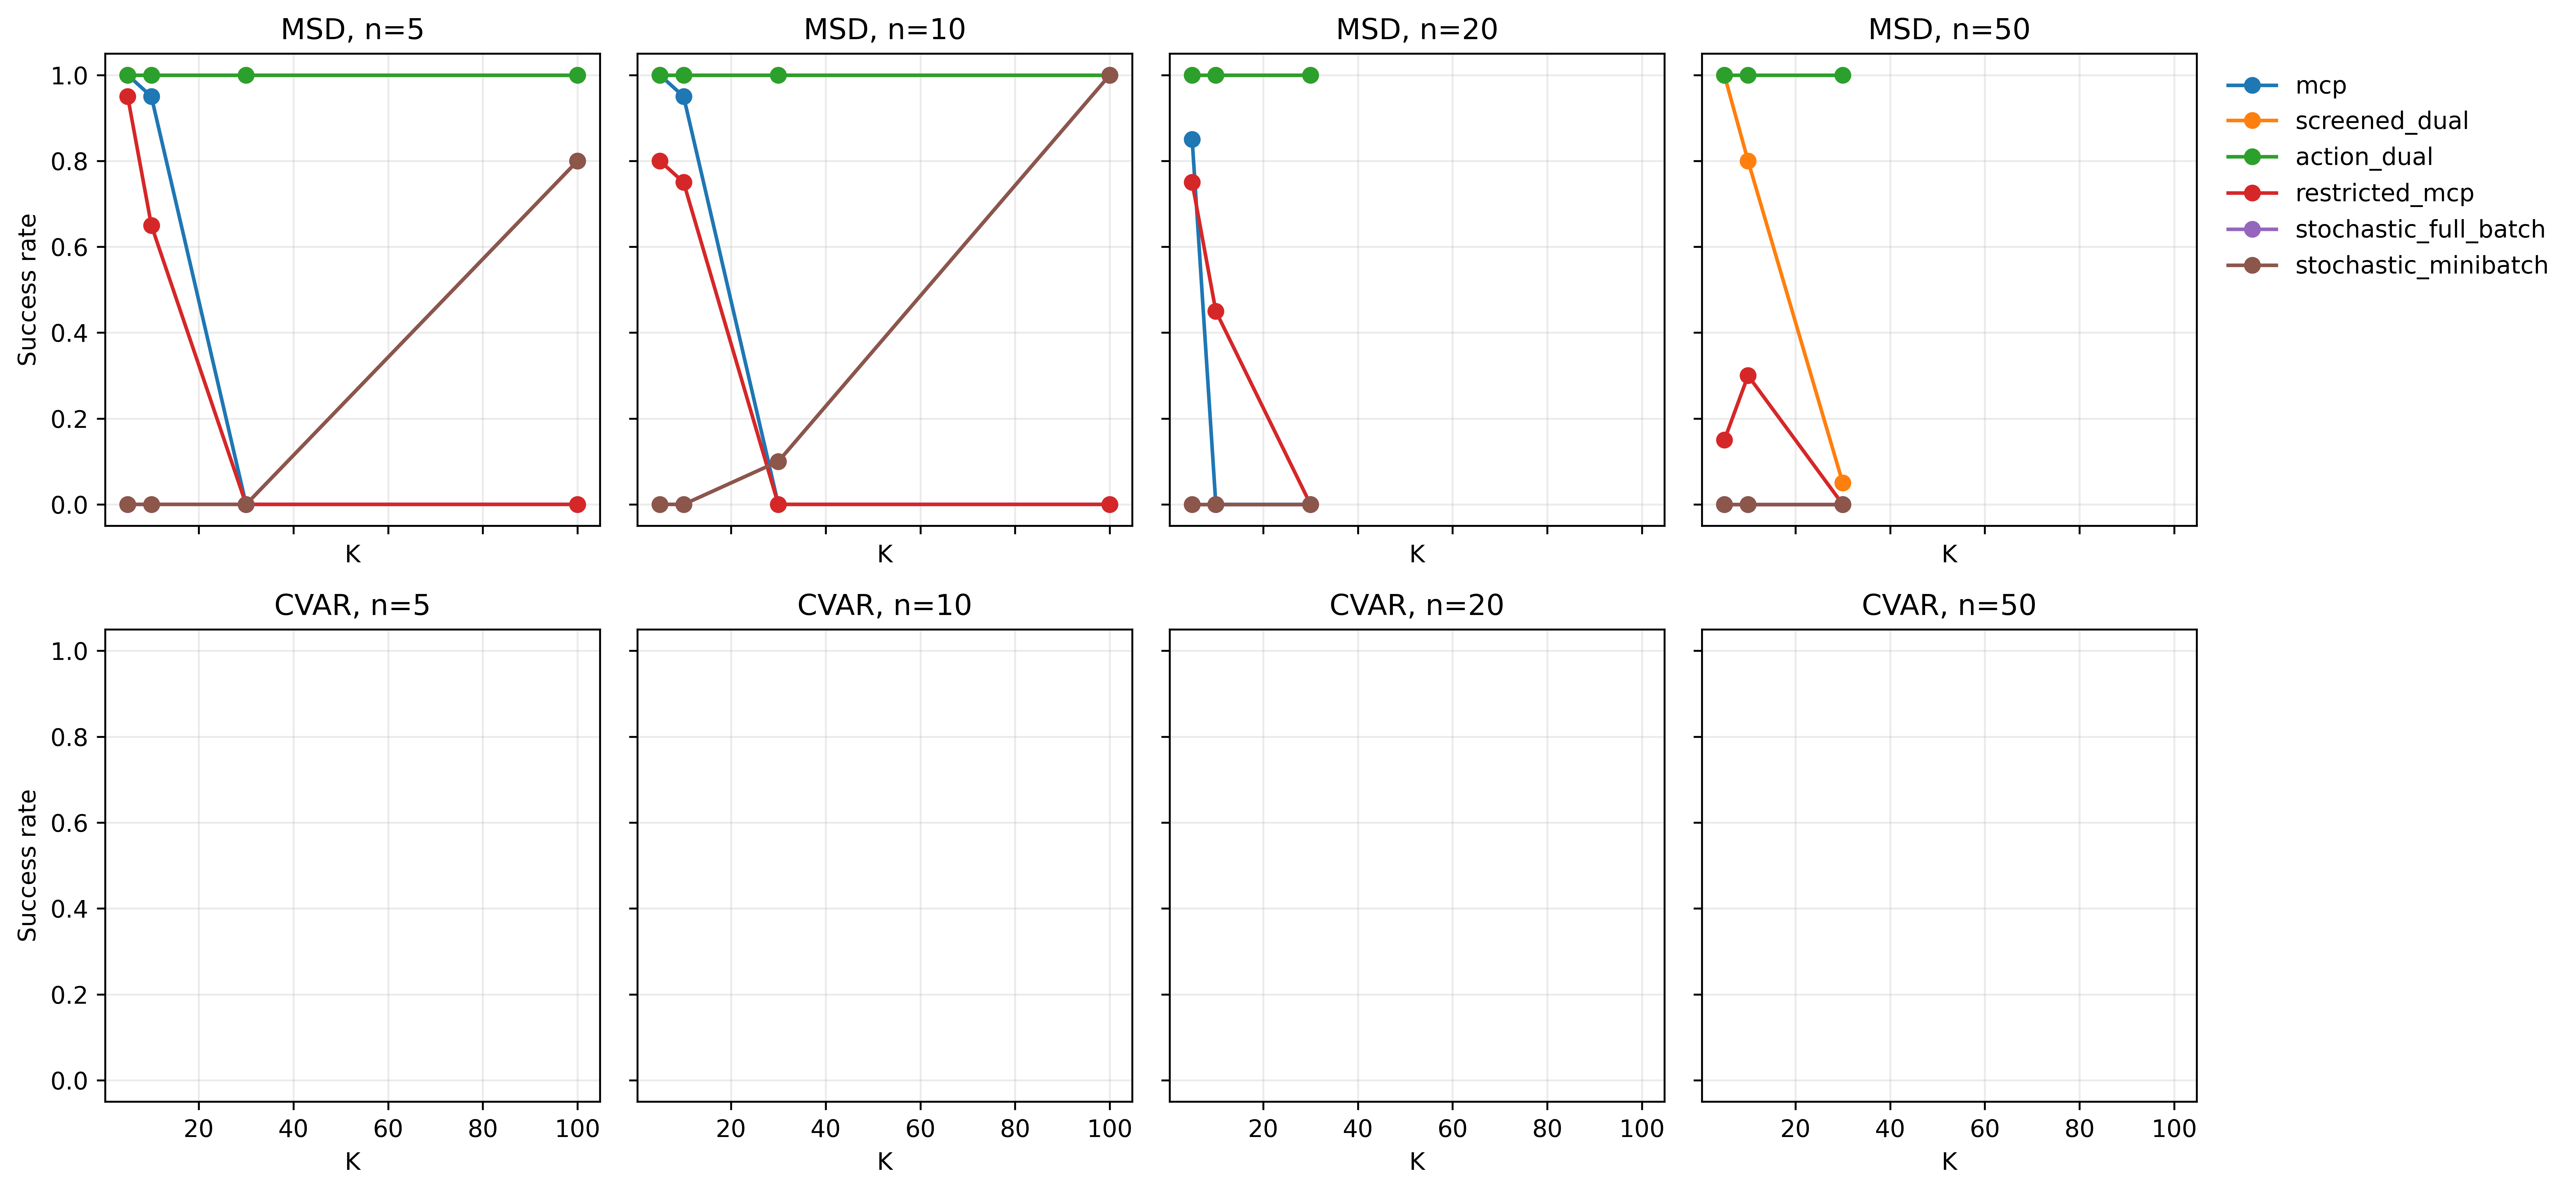

In [72]:
import matplotlib.pyplot as plt

K_grid = [5, 10, 30, 100, 250, 500]
n_grid = [5, 10, 20, 50]
risk_grid = ["msd", "cvar"]

fig, axes = plt.subplots(
    len(risk_grid),
    len(n_grid),
    figsize=(15, 7),
    dpi=600,
    sharey=True,
    sharex=True,
)

methods = [m.strip() for m in df["methods"].iloc[0].split(",")]
cmap = plt.get_cmap("tab10")
color_dict = {m: cmap(i % cmap.N) for i, m in enumerate(methods)}

for row, risk in enumerate(risk_grid):
    for col, n in enumerate(n_grid):
        ax = axes[row, col]
        s = df[(df["n"] == n) & (df["risk"] == risk)]

        for method in methods:
            method_df = (
                s.groupby("K", as_index=False)
                .agg(
                    **{
                        f"{method}_reps": ("seed", "count"),
                        f"{method}_succ_n": (f"{method}_success", "sum"),
                    }
                )
                .sort_values("K")
            )

            if method_df.empty:
                continue

            method_df[f"{method}_succ_rate"] = (
                method_df[f"{method}_succ_n"] / method_df[f"{method}_reps"]
            )

            ax.plot(
                method_df["K"],
                method_df[f"{method}_succ_rate"],
                "o-",
                label=method if row == 0 and col == len(n_grid) - 1 else "_nolegend_",
                color=color_dict[method],
            )

        ax.set_title(f"{risk.upper()}, n={n}")
        ax.set_xlabel("K")
        ax.grid(alpha=0.25)

    axes[row, 0].set_ylabel("Success rate")

axes[0, -1].legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()